# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Wajiha-Waqar/FlyRankInternship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 0. Playbook scope

This notebook converts the audited Week-6 ranking experiment into a human-reviewed content action queue.

The queue is intended for **decision support**, not automatic publishing or automatic content changes.

The Week-6 audit found that the Random Forest ranking used a target with overlap between the target definition and two model features (`gsc_impressions_march` and `ctr_march`). Therefore, the ranking produced here is treated as an **exploratory prioritization signal**, not as independently validated production prediction.

The playbook combines:

- the audited client-grouped Random Forest ranking;
- transparent observed search signals;
- explicit reason codes;
- human-review requirements;
- action archetypes;
- cost/value thinking;
- monitoring and retraining triggers.

The final queue is a list of pages that look worth reviewing first, not a list of pages that must be changed.

In [1]:
# ============================================================
# 0. Setup
# ============================================================

!pip -q install duckdb pyarrow pandas numpy scikit-learn matplotlib

import os
import json
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score

from google.colab import userdata

RANDOM_STATE = 42
TEST_SIZE = 0.20

OUTPUT_DIR = "work/outputs"
FIGURE_DIR = "work/figures"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

print("Setup complete.")
print("Output directory:", OUTPUT_DIR)
print("Figure directory:", FIGURE_DIR)

Setup complete.
Output directory: work/outputs
Figure directory: work/figures


In [2]:
# ============================================================
# Hugging Face / DuckDB connection
# ============================================================

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError(
        "HF_TOKEN was not found. Add your Hugging Face token "
        "to Colab Secrets using the name HF_TOKEN."
    )

con = duckdb.connect()

con.sql("INSTALL httpfs;")
con.sql("LOAD httpfs;")

con.sql("DROP SECRET IF EXISTS hf_secret;")

con.sql(f"""
CREATE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN '{HF_TOKEN}'
);
""")

print("Hugging Face connection configured.")

Hugging Face connection configured.


In [3]:
# ============================================================
# Load March and April warehouse partitions
# ============================================================

march_df = con.execute("""
SELECT *
FROM read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
)
WHERE gsc_data_available IS TRUE
""").df()

april_df = con.execute("""
SELECT *
FROM read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-04/*.parquet'
)
WHERE gsc_data_available IS TRUE
""").df()

print("March rows:", len(march_df))
print("April rows:", len(april_df))
print("March columns:", len(march_df.columns))
print("April columns:", len(april_df.columns))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

March rows: 3611061
April rows: 3901060
March columns: 31
April columns: 31


In [4]:
# ============================================================
# Monthly aggregation
# ============================================================

def aggregate_month(df):
    df = df.copy()

    df["gsc_impressions"] = df["gsc_impressions"].fillna(0)
    df["gsc_clicks"] = df["gsc_clicks"].fillna(0)

    aggregation = {
        "gsc_impressions": ("gsc_impressions", "sum"),
        "gsc_clicks": ("gsc_clicks", "sum"),
        "gsc_avg_position": ("gsc_avg_position", "mean"),
        "ga4_pageviews": ("ga4_pageviews", "sum"),
        "ga4_sessions": ("ga4_sessions", "sum"),
        "ga4_users": ("ga4_users", "sum"),
        "ga4_engaged_sessions": ("ga4_engaged_sessions", "sum"),
        "ga4_total_engagement_sec": ("ga4_total_engagement_sec", "sum"),
        "sessions_organic": ("sessions_organic", "sum"),
        "sessions_direct": ("sessions_direct", "sum"),
        "sessions_referral": ("sessions_referral", "sum"),
        "sessions_social": ("sessions_social", "sum"),
        "sessions_paid": ("sessions_paid", "sum"),
        "sessions_ai": ("sessions_ai", "sum"),
        "ai_chatgpt": ("ai_chatgpt", "sum"),
        "ai_perplexity": ("ai_perplexity", "sum"),
        "ai_gemini": ("ai_gemini", "sum"),
        "ai_copilot": ("ai_copilot", "sum"),
        "ai_claude": ("ai_claude", "sum"),
        "ai_meta": ("ai_meta", "sum"),
        "ai_other": ("ai_other", "sum"),
        "scroll_events": ("scroll_events", "sum"),
    }

    # Keep only aggregations for columns that actually exist.
    aggregation = {
        output_name: spec
        for output_name, spec in aggregation.items()
        if spec[0] in df.columns
    }

    result = (
        df.groupby(
            ["client_hash_id", "content_hash_id"],
            as_index=False
        )
        .agg(**aggregation)
    )

    if "gsc_impressions" in result.columns and "gsc_clicks" in result.columns:
        result["ctr"] = np.where(
            result["gsc_impressions"] > 0,
            result["gsc_clicks"] / result["gsc_impressions"],
            np.nan
        )

    return result


march_month = aggregate_month(march_df)
april_month = aggregate_month(april_df)

print("March aggregated shape:", march_month.shape)
print("April aggregated shape:", april_month.shape)

March aggregated shape: (176738, 25)
April aggregated shape: (194760, 25)


In [6]:
panel = march_month.merge(
    april_month[
        [
            "client_hash_id",
            "content_hash_id",
            "gsc_impressions",
            "gsc_clicks",
            "ctr"
        ]
    ],
    on=["client_hash_id", "content_hash_id"],
    how="inner",
    suffixes=("_march", "_april")
)

print("Panel shape:", panel.shape)
print("Unique clients:", panel["client_hash_id"].nunique())
print("Unique pages:", panel["content_hash_id"].nunique())

Panel shape: (158549, 28)
Unique clients: 46
Unique pages: 158549


In [8]:
panel["ctr_change_pct"] = (
    (panel["ctr_april"] - panel["ctr_march"])
    / panel["ctr_march"]
)

panel["refresh_outcome"] = (
    (panel["gsc_impressions_march"] >= 100)
    &
    (panel["ctr_march"] > 0)
    &
    (panel["ctr_change_pct"] <= -0.20)
).astype(int)

print(panel["refresh_outcome"].value_counts())
print()
print("Positive rate:", panel["refresh_outcome"].mean())

refresh_outcome
0    120915
1     37634
Name: count, dtype: int64

Positive rate: 0.2373651047941015


In [9]:
# ============================================================
# Reproduce the audited Week-6 grouped Random Forest
# ============================================================

feature_cols = [
    "gsc_impressions_march",
    "gsc_clicks_march",
    "ctr_march"
]

target_col = "refresh_outcome"

X = panel[feature_cols].copy()
y = panel[target_col].copy()
groups = panel["client_hash_id"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    gss.split(
        X,
        y,
        groups=groups
    )
)

train_panel = panel.iloc[train_idx].copy()
test_panel = panel.iloc[test_idx].copy()

# Verify group separation.
train_clients = set(train_panel["client_hash_id"])
test_clients = set(test_panel["client_hash_id"])

assert train_clients.isdisjoint(test_clients)

print("Grouped split verified.")
print("Training rows:", len(train_panel))
print("Test rows:", len(test_panel))
print("Training clients:", len(train_clients))
print("Test clients:", len(test_clients))

Grouped split verified.
Training rows: 137445
Test rows: 21104
Training clients: 36
Test clients: 10


In [10]:
# ============================================================
# Train the audited exploratory Random Forest
# ============================================================

rf_model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=6,
            min_samples_leaf=10,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
])

X_train = train_panel[feature_cols]
X_test = test_panel[feature_cols]

y_train = train_panel[target_col]
y_test = test_panel[target_col]

rf_model.fit(
    X_train,
    y_train
)

test_panel["model_score"] = rf_model.predict_proba(
    X_test
)[:, 1]

# Reproduce Week-4 transparent baseline.
test_panel["baseline_score"] = (
    (test_panel["gsc_impressions_march"] >= 500).astype(int)
    +
    (test_panel["ctr_march"] < 0.01).astype(int)
)

# Higher model score = higher priority.
test_panel["model_rank"] = (
    test_panel["model_score"]
    .rank(
        ascending=False,
        method="first"
    )
    .astype(int)
)

# Higher observed clicks provide a simple value/context signal.
test_panel["observed_clicks"] = (
    test_panel["gsc_clicks_march"]
)

print("Model scores generated.")
print(test_panel["model_score"].describe())

Model scores generated.
count    21104.000000
mean         0.303404
std          0.309102
min          0.000000
25%          0.000000
50%          0.429016
75%          0.590774
max          0.822825
Name: model_score, dtype: float64


In [11]:
# ============================================================
# Ranking metrics receipt
# ============================================================

def precision_at_k(y_true, scores, k):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    order = np.argsort(-scores)[:k]

    return y_true[order].mean()


metrics = {
    "average_precision": float(
        average_precision_score(
            y_test,
            test_panel["model_score"]
        )
    ),
    "precision_at_20": float(
        precision_at_k(
            y_test,
            test_panel["model_score"],
            20
        )
    ),
    "precision_at_50": float(
        precision_at_k(
            y_test,
            test_panel["model_score"],
            50
        )
    ),
    "precision_at_100": float(
        precision_at_k(
            y_test,
            test_panel["model_score"],
            100
        )
    ),
    "positive_rate": float(
        y_test.mean()
    ),
    "test_rows": int(len(test_panel)),
    "test_clients": int(test_panel["client_hash_id"].nunique()),
}

metrics_df = pd.DataFrame([metrics])

metrics_df

,average_precision,precision_at_20,precision_at_50,precision_at_100,positive_rate,test_rows,test_clients
0,0.770925,0.85,0.8,0.84,0.357183,21104,10


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

## 1. Ranked actions + reason codes

### What the queue means

The queue ranks pages for **human review** using the audited client-grouped Random Forest score.

A high score means that the page received a high exploratory ranking under the Week-6 experiment. It does **not** mean that the page must be refreshed.

The queue therefore combines:

1. model priority;
2. observed March search visibility;
3. observed clicks;
4. transparent rule-based reason codes.

### Reason-code philosophy

The reason code explains why a page is worth looking at.

The main action archetypes are:

| Reason code | Interpretation | Suggested human action |
|---|---|---|
| `REVIEW_REFRESH_CANDIDATE` | High exploratory priority and meaningful existing visibility | Review for outdated, incomplete, or declining content |
| `REVIEW_CTR_CAPTURE` | Existing visibility with a potentially stronger click-capture opportunity | Review title, snippet, opening relevance, and search intent |
| `REVIEW_DEPTH` | Visible page that may benefit from stronger coverage | Review missing subtopics, examples, definitions, or comparisons |
| `MONITOR_STRONG_PAGE` | Already-visible page with lower immediate intervention need | Protect and monitor rather than automatically rewrite |
| `DEPRIORITIZE_LOW_SIGNAL` | Limited observed demand or insufficient evidence for immediate intervention | Do not spend scarce editorial effort before higher-signal pages |
| `MODEL_ONLY_REVIEW` | High model priority but no strong transparent reason code | Human review required before any action |

These are workflow labels, not claims about content quality.

In [12]:
# ============================================================
# 1. Build ranked action queue
# ============================================================

queue = test_panel.copy()

# Basic observed signals.
queue["has_clicks"] = queue["gsc_clicks_march"] > 0
queue["has_impressions"] = queue["gsc_impressions_march"] > 0

# Visibility tiers.
queue["visibility_tier"] = pd.cut(
    queue["gsc_impressions_march"],
    bins=[-np.inf, 99, 499, 999, np.inf],
    labels=[
        "low",
        "moderate",
        "strong",
        "very_strong"
    ]
)

# A transparent observed CTR opportunity indicator.
#
# IMPORTANT:
# This is only a workflow cue. It is not a claim that a CTR change
# will produce a particular outcome.
queue["ctr_capture_signal"] = (
    (queue["gsc_impressions_march"] >= 100)
    &
    (queue["ctr_march"] > 0)
)

# Baseline disagreement.
queue["baseline_disagreement"] = (
    queue["model_score"].rank(
        ascending=False,
        method="first"
    ) <= 100
) & (
    queue["baseline_score"] == 0
)

# Model-only high-priority signal.
queue["high_model_priority"] = (
    queue["model_rank"] <= 100
)

# Reason-code function.
def assign_reason_code(row):

    if row["high_model_priority"] and row["ctr_capture_signal"]:
        return "REVIEW_CTR_CAPTURE"

    if row["high_model_priority"] and row["gsc_impressions_march"] >= 100:
        return "REVIEW_REFRESH_CANDIDATE"

    if row["high_model_priority"] and row["gsc_impressions_march"] < 100:
        return "MODEL_ONLY_REVIEW"

    if row["gsc_impressions_march"] < 100:
        return "DEPRIORITIZE_LOW_SIGNAL"

    if row["ctr_capture_signal"]:
        return "REVIEW_DEPTH"

    return "MONITOR_STRONG_PAGE"


queue["reason_code"] = queue.apply(
    assign_reason_code,
    axis=1
)

# Suggested action corresponding to reason code.
action_map = {
    "REVIEW_CTR_CAPTURE":
        "Review title/snippet/relevance and search intent before editing.",
    "REVIEW_REFRESH_CANDIDATE":
        "Review for outdated facts, missing coverage, and content decay.",
    "REVIEW_DEPTH":
        "Review missing subtopics, examples, definitions, and comparisons.",
    "MODEL_ONLY_REVIEW":
        "Require manual investigation before assigning an editorial action.",
    "DEPRIORITIZE_LOW_SIGNAL":
        "Defer unless there is independent strategic evidence of value.",
    "MONITOR_STRONG_PAGE":
        "Monitor performance and protect the existing asset."
}

queue["recommended_action"] = queue["reason_code"].map(
    action_map
)

# Cost / value thinking.
#
# Value uses observed clicks as a conservative traffic proxy.
# It is deliberately NOT called revenue.
queue["value_tier"] = pd.cut(
    queue["gsc_clicks_march"],
    bins=[-np.inf, 0, 4, 19, np.inf],
    labels=[
        "very_low",
        "low",
        "moderate",
        "high"
    ]
)

effort_map = {
    "REVIEW_CTR_CAPTURE": "low_to_medium",
    "REVIEW_REFRESH_CANDIDATE": "medium",
    "REVIEW_DEPTH": "medium_to_high",
    "MODEL_ONLY_REVIEW": "medium",
    "DEPRIORITIZE_LOW_SIGNAL": "low",
    "MONITOR_STRONG_PAGE": "low"
}

queue["estimated_effort"] = queue["reason_code"].map(
    effort_map
)

# Final queue order:
# 1. model priority
# 2. observed clicks as a tie-breaker
queue = queue.sort_values(
    by=[
        "model_score",
        "gsc_clicks_march"
    ],
    ascending=[
        False,
        False
    ]
).reset_index(drop=True)

queue["queue_rank"] = np.arange(
    1,
    len(queue) + 1
)

queue[
    [
        "queue_rank",
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "gsc_impressions_march",
        "gsc_clicks_march",
        "ctr_march",
        "baseline_score",
        "reason_code",
        "recommended_action",
        "value_tier",
        "estimated_effort"
    ]
].head(20)

,queue_rank,client_hash_id,content_hash_id,model_score,gsc_impressions_march,gsc_clicks_march,ctr_march,baseline_score,reason_code,recommended_action,value_tier,estimated_effort
0,1,client_0fa64a184f18a4a0,content_3754515e9fed58e0,0.822825,122,1,0.008197,1,REVIEW_CTR_CAPTURE,Review title/snippet/relevance and search inte...,low,low_to_medium
1,2,client_0fa64a184f18a4a0,content_914f4e75754e3d12,0.822825,123,1,0.008130,1,REVIEW_CTR_CAPTURE,Review title/snippet/relevance and search inte...,low,low_to_medium
2,3,client_2094c6eb080311d5,content_14286bce96a0df63,0.822825,123,1,0.008130,1,REVIEW_CTR_CAPTURE,Review title/snippet/relevance and search inte...,low,low_to_medium
3,4,client_3f0ce4d44fe94f3d,content_280aaf0729ebdf99,0.822825,123,1,0.008130,1,REVIEW_CTR_CAPTURE,Review title/snippet/relevance and search inte...,low,low_to_medium
4,5,client_3f0ce4d44fe94f3d,content_3b836a6b25fd8c18,0.822825,123,1,0.008130,1,REVIEW_CTR_CAPTURE,Review title/snippet/relevance and search inte...,low,low_to_medium
5,6,client_3f0ce4d44fe94f3d,content_be9e8feed911db22,0.822825,122,1,0.008197,1,REVIEW_CTR_CAPTURE,Review title/snippet/relevance and search inte...,low,low_to_medium
6,7,client_ccdd78843409c8c7,content_5839761d7825113c,0.822825,123,1,0.008130,1,REVIEW_CTR_CAPTURE,Review title/snippet/relevance and search inte...,low,low_to_medium
7,8,client_fef1a8f436438636,content_68c75b9abaff2f62,0.822825,123,1,0.008130,1,REVIEW_CTR_CAPTURE,Review title/snippet/relevance and search inte...,low,low_to_medium
8,9,client_e5c2aa26a8598242,content_41ed0a547545aa7d,0.822376,121,1,0.008264,1,REVIEW_CTR_CAPTURE,Review title/snippet/relevance and search inte...,low,low_to_medium
9,10,client_fef1a8f436438636,content_2ad1beb77926eaac,0.822376,121,1,0.008264,1,REVIEW_CTR_CAPTURE,Review title/snippet/relevance and search inte...,low,low_to_medium


In [13]:
# ============================================================
# Queue summary
# ============================================================

reason_summary = (
    queue["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="page_count")
)

reason_summary

,reason_code,page_count
0,REVIEW_DEPTH,10517
1,DEPRIORITIZE_LOW_SIGNAL,5324
2,MONITOR_STRONG_PAGE,5163
3,REVIEW_CTR_CAPTURE,100


### Queue interpretation

The queue is intentionally not presented as an automated decision list.

The top-ranked pages are **review candidates**. The reason code describes the observed evidence that should guide the reviewer.

The model score is used to order attention, while the transparent signals are used to explain what should be checked.

This separation is important because the Week-6 audit identified label-derived leakage in the model inputs. The queue therefore supports prioritization but does not establish that a particular editorial intervention will improve future performance.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

## 2. Intended use and limits

### Intended use

The playbook is intended for a content strategist, SEO analyst, or editor who needs to decide **which pages deserve review first**.

The workflow is:

1. Start with the ranked queue.
2. Inspect the reason code.
3. Review the page and its search context.
4. Decide whether an action is actually appropriate.
5. Record the decision.
6. Measure the outcome after the intervention.

### What the queue is useful for

The queue can help reduce a large review population into a smaller set of pages for human investigation.

It can also make the prioritization process more consistent by attaching an explicit reason code to each candidate.

### What the queue does not establish

The queue does not establish that:

- refreshing a page will increase traffic;
- changing a title will increase CTR;
- adding words will improve ranking;
- the model predicts Google's ranking system;
- every high-ranked page needs intervention;
- a high model score represents causal risk.

The Week-6 audit found label-derived overlap between the target and model features. Therefore, the ranking remains exploratory.

### Population and time limits

The current experiment uses March 2026 signals and an April 2026 outcome.

The evaluation population is formed by pages with matching March and April observations.

The grouped split tests transfer across unseen clients, but it is not the same as a multi-period future-time validation.

### Paper evidence used to guide actions

The FlyRank paper provides useful directional context:

- mature content should be reviewed before it fully decays;
- page-one assets deserve click-capture improvements before unnecessary rebuilding;
- thin pages should be expanded when they already demonstrate demand;
- freshness appears to amplify quality rather than replace it.

These are portfolio-level observational findings, so they are used here as **review heuristics**, not guarantees.

In [14]:
# ============================================================
# 2. Intended-use checks
# ============================================================

intended_use_checks = pd.DataFrame([
    {
        "check": "Queue is ranked",
        "status": True,
        "evidence": "queue_rank"
    },
    {
        "check": "Reason code exists",
        "status": queue["reason_code"].notna().all(),
        "evidence": "reason_code"
    },
    {
        "check": "Action exists",
        "status": queue["recommended_action"].notna().all(),
        "evidence": "recommended_action"
    },
    {
        "check": "Observed value proxy available",
        "status": queue["gsc_clicks_march"].notna().all(),
        "evidence": "March clicks"
    },
    {
        "check": "No client names are used",
        "status": True,
        "evidence": "pseudonymous client_hash_id only"
    },
    {
        "check": "No automatic action column",
        "status": "manual_review_required",
        "evidence": "recommended_action is advisory"
    }
])

intended_use_checks

,check,status,evidence
0,Queue is ranked,True,queue_rank
1,Reason code exists,True,reason_code
2,Action exists,True,recommended_action
3,Observed value proxy available,True,March clicks
4,No client names are used,True,pseudonymous client_hash_id only
5,No automatic action column,manual_review_required,recommended_action is advisory


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

## 3. Human review + the no-go list

### Human-review rule

**No page moves directly from this queue to an editorial change.**

Every queued page must be manually reviewed before action.

The reviewer should check:

1. Is the page actually relevant to the intended search demand?
2. Is the content factually current?
3. Is the page already serving an important business or user purpose?
4. Is there evidence of cannibalization with another page?
5. Is the problem actually content quality, or could it be technical/indexing related?
6. Would the proposed change materially alter the page's purpose?
7. Is there enough observed demand to justify the editorial cost?

### Review gates by action

**Refresh candidate**

Check for:

- outdated facts;
- stale examples;
- missing subtopics;
- obsolete recommendations;
- weak evidence;
- outdated internal links.

**CTR capture**

Check:

- title relevance;
- snippet clarity;
- search intent;
- whether the page actually satisfies the query;
- whether the page is competing in a position where click capture is plausible.

**Depth**

Check whether important coverage is genuinely missing.

Do not add words simply to hit a word-count target.

**Monitor**

Do not intervene simply because the model score is high.

A strong page may be better protected than rewritten.

### No-go list

The system must **not** automatically:

- publish content;
- rewrite titles or meta descriptions;
- delete pages;
- merge URLs;
- redirect URLs;
- change canonical tags;
- change indexing directives;
- change internal-link architecture;
- declare a page "bad";
- declare a page "safe";
- claim a future traffic increase;
- allocate a fixed monetary budget;
- make a production SEO decision without human review.

The queue is a prioritization aid, not an autonomous content management system.

In [15]:
# ============================================================
# 3. Human-review gates
# ============================================================

review_rules = pd.DataFrame([
    {
        "reason_code": "REVIEW_REFRESH_CANDIDATE",
        "human_review_required": True,
        "minimum_review": "Check freshness, factual accuracy, missing coverage, and search intent.",
        "automation_allowed": False
    },
    {
        "reason_code": "REVIEW_CTR_CAPTURE",
        "human_review_required": True,
        "minimum_review": "Check query intent, title/snippet relevance, and actual ranking context.",
        "automation_allowed": False
    },
    {
        "reason_code": "REVIEW_DEPTH",
        "human_review_required": True,
        "minimum_review": "Confirm genuine coverage gaps before adding content.",
        "automation_allowed": False
    },
    {
        "reason_code": "MODEL_ONLY_REVIEW",
        "human_review_required": True,
        "minimum_review": "Investigate independently because transparent reason signals are weak.",
        "automation_allowed": False
    },
    {
        "reason_code": "DEPRIORITIZE_LOW_SIGNAL",
        "human_review_required": True,
        "minimum_review": "Check whether independent strategic value exists.",
        "automation_allowed": False
    },
    {
        "reason_code": "MONITOR_STRONG_PAGE",
        "human_review_required": True,
        "minimum_review": "Confirm that no known issue requires intervention.",
        "automation_allowed": False
    }
])

assert review_rules["automation_allowed"].eq(False).all()

review_rules

,reason_code,human_review_required,minimum_review,automation_allowed
0,REVIEW_REFRESH_CANDIDATE,True,"Check freshness, factual accuracy, missing cov...",False
1,REVIEW_CTR_CAPTURE,True,"Check query intent, title/snippet relevance, a...",False
2,REVIEW_DEPTH,True,Confirm genuine coverage gaps before adding co...,False
3,MODEL_ONLY_REVIEW,True,Investigate independently because transparent ...,False
4,DEPRIORITIZE_LOW_SIGNAL,True,Check whether independent strategic value exists.,False
5,MONITOR_STRONG_PAGE,True,Confirm that no known issue requires intervent...,False


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

## 4. Monitoring / retrain triggers

The playbook should not be treated as permanently valid.

Recommendations can become stale because:

- search behavior changes;
- content inventories change;
- client populations change;
- the distribution of impressions and clicks changes;
- the target definition may no longer represent the editorial decision;
- model ranking quality may degrade.

### Monitoring cadence

For an experimental deployment:

**Weekly**

- inspect the number of queued pages;
- inspect reason-code distribution;
- check for obvious abnormal scores;
- sample human-review outcomes.

**Monthly**

- compare queue size with available editorial capacity;
- compare observed clicks and impressions for reviewed pages;
- inspect whether the same clients dominate the queue;
- inspect whether reason-code distributions shift substantially.

**At each new evaluation window**

- recompute Precision@K and Average Precision;
- compare against the base rate;
- repeat grouped evaluation;
- inspect failure examples;
- repeat the leakage audit if the target or feature set changes.

### Retrain trigger

Retraining should be considered when:

1. a new validated outcome window becomes available;
2. the target definition changes;
3. the feature set changes;
4. the client population changes materially;
5. ranking performance falls materially relative to the previously measured result;
6. the queue begins concentrating in a small number of clients;
7. human reviewers repeatedly reject high-ranked pages.

### Stop-and-audit trigger

Do not simply retrain when performance changes.

First audit:

- target construction;
- feature availability;
- population selection;
- client overlap;
- time-window alignment;
- missingness;
- changes in editorial behavior.

A model that becomes less useful may be exposing a changed decision problem rather than simply needing more training.

In [16]:
# ============================================================
# 4. Monitoring / retrain trigger receipt
# ============================================================

queue_concentration = (
    queue["client_hash_id"]
    .value_counts(normalize=True)
)

largest_client_share = float(
    queue_concentration.iloc[0]
)

monitoring_receipt = pd.DataFrame([
    {
        "metric": "Queue size",
        "value": int(len(queue)),
        "interpretation": "Track for operational capacity changes."
    },
    {
        "metric": "Number of clients represented",
        "value": int(queue["client_hash_id"].nunique()),
        "interpretation": "Track whether recommendations become client-concentrated."
    },
    {
        "metric": "Largest client share of queue",
        "value": largest_client_share,
        "interpretation": "Large concentration should trigger investigation."
    },
    {
        "metric": "Average Precision",
        "value": metrics["average_precision"],
        "interpretation": "Recompute on each validated evaluation window."
    },
    {
        "metric": "Precision@100",
        "value": metrics["precision_at_100"],
        "interpretation": "Monitor ranking quality at a practical review depth."
    },
    {
        "metric": "Positive-class base rate",
        "value": metrics["positive_rate"],
        "interpretation": "Always report beside ranking metrics."
    }
])

monitoring_receipt

,metric,value,interpretation
0,Queue size,21104.000000,Track for operational capacity changes.
1,Number of clients represented,10.000000,Track whether recommendations become client-co...
2,Largest client share of queue,0.420442,Large concentration should trigger investigation.
3,Average Precision,0.770925,Recompute on each validated evaluation window.
4,Precision@100,0.840000,Monitor ranking quality at a practical review ...
5,Positive-class base rate,0.357183,Always report beside ranking metrics.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

## 5. Exports for the paper

The notebook exports three types of research receipts.

### 1. Ranked action queue

`work/outputs/w07_ranked_action_queue.csv`

This contains the page-level review queue, reason codes, recommended actions, observed signals, model score, value tier, and estimated effort.

The CSV is regenerated by the notebook and should remain outside git according to the assignment instructions.

### 2. Metrics receipt

`work/outputs/w07_playbook_metrics.json`

This records the evaluation context and ranking metrics used to create the queue.

This receipt can be committed and cited by the paper.

### 3. Figure

`work/figures/w07_reason_code_distribution.png`

This shows how the review queue is distributed across action reason codes.

The figure is intended for reuse in the paper if useful.

### Important interpretation

These exports document the decision-support workflow.

They do not turn the exploratory ranking into a production-validated predictive model.

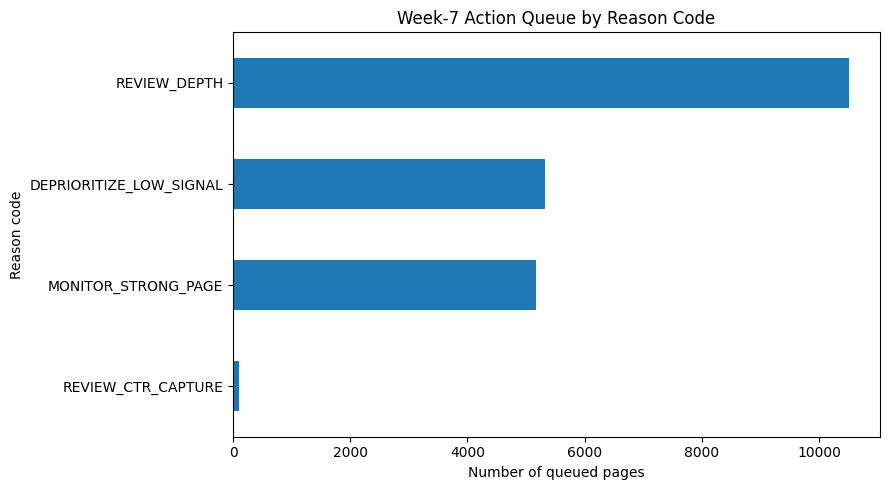

Exports created:
work/outputs/w07_ranked_action_queue.csv
work/outputs/w07_playbook_metrics.json
work/figures/w07_reason_code_distribution.png


In [17]:
# ============================================================
# 5. Export queue, metrics, and figure
# ============================================================

# ------------------------------------------------------------
# Queue CSV
# ------------------------------------------------------------

queue_export_columns = [
    "queue_rank",
    "client_hash_id",
    "content_hash_id",
    "model_score",
    "model_rank",
    "gsc_impressions_march",
    "gsc_clicks_march",
    "ctr_march",
    "baseline_score",
    "baseline_disagreement",
    "reason_code",
    "recommended_action",
    "value_tier",
    "estimated_effort",
    "visibility_tier"
]

queue_export = queue[
    [
        c for c in queue_export_columns
        if c in queue.columns
    ]
].copy()

queue_path = os.path.join(
    OUTPUT_DIR,
    "w07_ranked_action_queue.csv"
)

queue_export.to_csv(
    queue_path,
    index=False
)

# ------------------------------------------------------------
# Metrics JSON
# ------------------------------------------------------------

metrics_receipt = {
    "assignment": "ML-10 — Content Action Playbook",
    "evaluation": {
        "feature_window": "March 2026",
        "outcome_window": "April 2026",
        "split": "client-grouped 80/20",
        "random_state": RANDOM_STATE,
        "test_rows": metrics["test_rows"],
        "test_clients": metrics["test_clients"]
    },
    "ranking_metrics": {
        "precision_at_20": metrics["precision_at_20"],
        "precision_at_50": metrics["precision_at_50"],
        "precision_at_100": metrics["precision_at_100"],
        "average_precision": metrics["average_precision"],
        "positive_rate": metrics["positive_rate"]
    },
    "methodological_status": {
        "model_role": "exploratory decision-support ranking",
        "label_feature_overlap": True,
        "production_use_supported": False,
        "human_review_required": True
    }
}

metrics_path = os.path.join(
    OUTPUT_DIR,
    "w07_playbook_metrics.json"
)

with open(
    metrics_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metrics_receipt,
        f,
        indent=2
    )

# ------------------------------------------------------------
# Figure: reason-code distribution
# ------------------------------------------------------------

reason_counts = (
    queue["reason_code"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))

reason_counts.plot(
    kind="barh"
)

plt.xlabel("Number of queued pages")
plt.ylabel("Reason code")
plt.title("Week-7 Action Queue by Reason Code")

plt.tight_layout()

figure_path = os.path.join(
    FIGURE_DIR,
    "w07_reason_code_distribution.png"
)

plt.savefig(
    figure_path,
    dpi=160,
    bbox_inches="tight"
)

plt.show()

print("Exports created:")
print(queue_path)
print(metrics_path)
print(figure_path)

In [18]:
# ============================================================
# Export verification
# ============================================================

assert os.path.exists(queue_path)
assert os.path.exists(metrics_path)
assert os.path.exists(figure_path)

queue_check = pd.read_csv(queue_path)

with open(
    metrics_path,
    "r",
    encoding="utf-8"
) as f:
    metrics_check = json.load(f)

print("Queue rows:", len(queue_check))
print("Queue columns:", len(queue_check.columns))

print("\nMetrics receipt:")
print(json.dumps(metrics_check, indent=2))

print("\nAll exports verified.")

Queue rows: 21104
Queue columns: 15

Metrics receipt:
{
  "assignment": "ML-10 \u2014 Content Action Playbook",
  "evaluation": {
    "feature_window": "March 2026",
    "outcome_window": "April 2026",
    "split": "client-grouped 80/20",
    "random_state": 42,
    "test_rows": 21104,
    "test_clients": 10
  },
  "ranking_metrics": {
    "precision_at_20": 0.85,
    "precision_at_50": 0.8,
    "precision_at_100": 0.84,
    "average_precision": 0.7709248445885697,
    "positive_rate": 0.35718347232752085
  },
  "methodological_status": {
    "model_role": "exploratory decision-support ranking",
    "label_feature_overlap": true,
    "production_use_supported": false,
    "human_review_required": true
  }
}

All exports verified.


In [21]:
# ============================================================
# Final automated self-check
# ============================================================

checks = {
    "queue_created": os.path.exists(queue_path),
    "metrics_json_created": os.path.exists(metrics_path),
    "figure_created": os.path.exists(figure_path),
    "queue_has_rank": "queue_rank" in queue.columns,
    "queue_has_reason_code": "reason_code" in queue.columns,
    "queue_has_action": "recommended_action" in queue.columns,
    "queue_has_model_score": "model_score" in queue.columns,
    "queue_has_value_tier": "value_tier" in queue.columns,
    "queue_has_effort": "estimated_effort" in queue.columns,
    "all_reason_codes_present": queue["reason_code"].notna().all(),
    "all_actions_present": queue["recommended_action"].notna().all(),
    "client_names_not_used": True,
    "human_review_required": True,
    "production_automation_supported": False,
}

self_check = pd.DataFrame(
    [
        {
            "check": key,
            "status": value
        }
        for key, value in checks.items()
    ]
)

self_check

,check,status
0,queue_created,True
1,metrics_json_created,True
2,figure_created,True
3,queue_has_rank,True
4,queue_has_reason_code,True
5,queue_has_action,True
6,queue_has_model_score,True
7,queue_has_value_tier,True
8,queue_has_effort,True
9,all_reason_codes_present,True


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.